/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Rössler benchmark data check
----------------------------
Loaded file: rossler_chaotic_data.csv
Data shape: (21, 2000)
Expected rows: 21
Number of sampled trajectories: 2000
Number of saved timepoints per trajectory: 7
Sampled post-transient times: [ 70.          78.33333333  86.66666667  95.         103.33333333
 111.66666667 120.        ]
Direct transition interval Delta t: 8.3333
Finite values only: True

Displayed saved sample summary
------------------------------
Sample index: 0
x range: -8.1896 to 6.7843
y range: -7.9008 to 3.9238
z range: 0.0142 to 7.7594

Dense visualization trajectory summary
--------------------------------------
Post-transient x range: -8.9581 to 11.2915
Post-transient y range: -10.6163 to 7.7133
Post-transient z range: 0.0137 to 21.3055


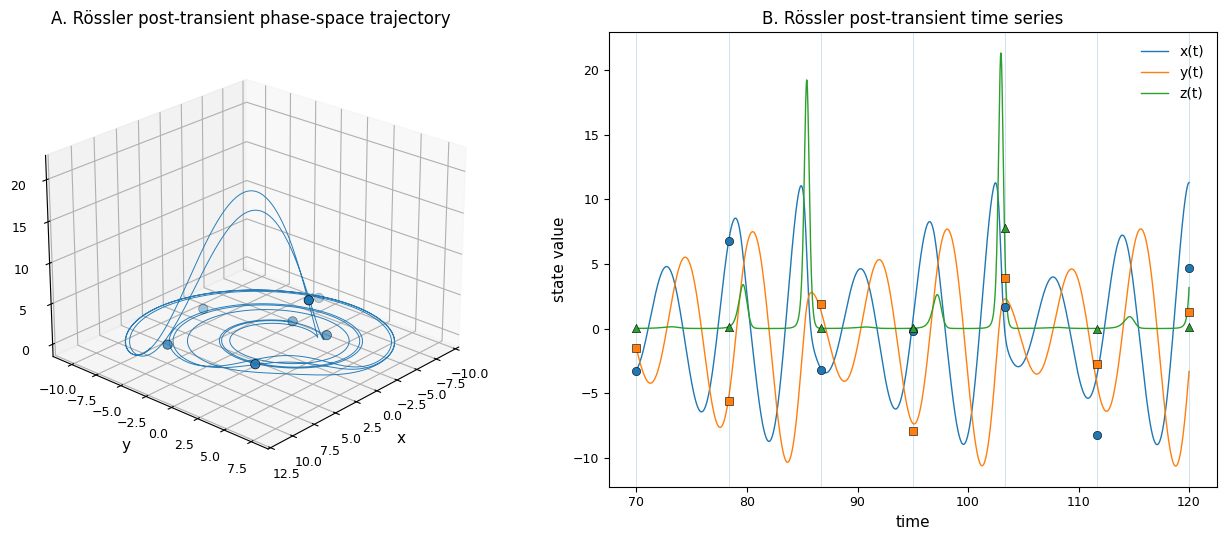


Saved PDF: supplementary_rossler_benchmark_trajectory.pdf
Saved JPEG: supplementary_rossler_benchmark_trajectory.jpeg
Status: Figure is ready for Supplementary Materials.


In [1]:
# ============================================================
# Supplementary Rössler benchmark figure
# Uses saved DynML sparse benchmark data + dense representative
# trajectory for visualization.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path

# ------------------------
# Files
# ------------------------
csv_file = Path("rossler_chaotic_data.csv")
output_pdf = "supplementary_rossler_benchmark_trajectory.pdf"
output_jpeg = "supplementary_rossler_benchmark_trajectory.jpeg"

# ------------------------
# Rössler parameters
# ------------------------
a, b, c = 0.2, 0.2, 5.7
base_x0 = np.array([0.1, 0.0, 0.0])

T = 7
t_total = 120
transient_time = 70
sample_times = np.linspace(transient_time, t_total, T)

# ------------------------
# Load saved sparse benchmark data
# ------------------------
if not csv_file.exists():
    raise FileNotFoundError(f"Could not find {csv_file}")

df = pd.read_csv(csv_file)
data = df.values

expected_rows = 3 * T
if data.shape[0] != expected_rows:
    raise ValueError(f"Expected {expected_rows} rows, but found {data.shape[0]} rows.")

if not np.all(np.isfinite(data)):
    raise ValueError("Saved Rössler data contain NaN or infinite values.")

num_samples = data.shape[1]

# Rows are x1..x7, y1..y7, z1..z7
x_sparse_all = data[0:T, :]
y_sparse_all = data[T:2*T, :]
z_sparse_all = data[2*T:3*T, :]

# Choose one saved trajectory/sample to display
sample_index = 0
x_sparse = x_sparse_all[:, sample_index]
y_sparse = y_sparse_all[:, sample_index]
z_sparse = z_sparse_all[:, sample_index]

# ------------------------
# Define Rössler system
# ------------------------
def rossler(t, X):
    x, y, z = X
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return [dx, dy, dz]

# ------------------------
# Generate dense representative trajectory for visualization
# ------------------------
t_dense = np.linspace(0, t_total, 20000)

sol_dense = solve_ivp(
    rossler,
    (0, t_total),
    base_x0,
    t_eval=t_dense,
    rtol=1e-9,
    atol=1e-12
)

if not sol_dense.success:
    raise RuntimeError("Dense Rössler integration failed: " + sol_dense.message)

mask = t_dense >= transient_time
t_plot = t_dense[mask]
x_plot = sol_dense.y[0, mask]
y_plot = sol_dense.y[1, mask]
z_plot = sol_dense.y[2, mask]

# ------------------------
# Basic data checks
# ------------------------
print("Rössler benchmark data check")
print("----------------------------")
print(f"Loaded file: {csv_file}")
print(f"Data shape: {data.shape}")
print(f"Expected rows: {expected_rows}")
print(f"Number of sampled trajectories: {num_samples}")
print(f"Number of saved timepoints per trajectory: {T}")
print(f"Sampled post-transient times: {sample_times}")
print(f"Direct transition interval Delta t: {(t_total - transient_time) / (T - 1):.4f}")
print(f"Finite values only: {np.all(np.isfinite(data))}")
print()
print("Displayed saved sample summary")
print("------------------------------")
print(f"Sample index: {sample_index}")
print(f"x range: {x_sparse.min():.4f} to {x_sparse.max():.4f}")
print(f"y range: {y_sparse.min():.4f} to {y_sparse.max():.4f}")
print(f"z range: {z_sparse.min():.4f} to {z_sparse.max():.4f}")
print()
print("Dense visualization trajectory summary")
print("--------------------------------------")
print(f"Post-transient x range: {x_plot.min():.4f} to {x_plot.max():.4f}")
print(f"Post-transient y range: {y_plot.min():.4f} to {y_plot.max():.4f}")
print(f"Post-transient z range: {z_plot.min():.4f} to {z_plot.max():.4f}")

# ------------------------
# Plot
# ------------------------
fig = plt.figure(figsize=(13, 5.5))

# A. 3D phase-space trajectory
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot(x_plot, y_plot, z_plot, linewidth=0.7, alpha=0.95)
ax1.scatter(
    x_sparse,
    y_sparse,
    z_sparse,
    s=45,
    marker="o",
    edgecolor="black",
    linewidth=0.5,
    zorder=5
)
ax1.set_title("A. Rössler post-transient phase-space trajectory", fontsize=12)
ax1.set_xlabel("x", fontsize=11)
ax1.set_ylabel("y", fontsize=11)
ax1.set_zlabel("z", fontsize=11)
ax1.view_init(elev=24, azim=42)
ax1.tick_params(labelsize=9)

# B. Time series
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t_plot, x_plot, linewidth=1.0, label="x(t)")
ax2.plot(t_plot, y_plot, linewidth=1.0, label="y(t)")
ax2.plot(t_plot, z_plot, linewidth=1.0, label="z(t)")

# Show all 7 sampled points for all three coordinates
ax2.scatter(sample_times, x_sparse, s=36, marker="o", edgecolor="black", linewidth=0.4, zorder=5)
ax2.scatter(sample_times, y_sparse, s=36, marker="s", edgecolor="black", linewidth=0.4, zorder=5)
ax2.scatter(sample_times, z_sparse, s=36, marker="^", edgecolor="black", linewidth=0.4, zorder=5)

# Vertical lines show the sparse sampling times
for t in sample_times:
    ax2.axvline(t, linewidth=0.6, alpha=0.25)

ax2.set_title("B. Rössler post-transient time series", fontsize=12)
ax2.set_xlabel("time", fontsize=11)
ax2.set_ylabel("state value", fontsize=11)
ax2.legend(frameon=False, fontsize=10, loc="upper right")
ax2.tick_params(labelsize=9)

plt.tight_layout()

plt.savefig(output_pdf, bbox_inches="tight")
plt.savefig(output_jpeg, dpi=600, bbox_inches="tight")
plt.show()

print()
print(f"Saved PDF: {output_pdf}")
print(f"Saved JPEG: {output_jpeg}")
print("Status: Figure is ready for Supplementary Materials.")